## Load Data and Drop Channel

In [797]:
import numpy as np

data = np.load("Datasets/Main.npz")
X = data["X_raw"]
y = data["y"]  

BAD_CHANNELS = [0,1,2,6,7]
X = np.delete(X, BAD_CHANNELS, axis=1)
print(X.shape)

(570, 3, 1750)


## !Experimental! Signal Augmentation

In [798]:
C3_data = X[:, 0, :]
CZ_data = X[:, 1, :]
C4_data = X[:, 2, :]

C3_augmented = C3_data * 4 / 7 + CZ_data * 2 / 7 + C4_data * 1 / 7
C4_augmented = C4_data * 4 / 7 + CZ_data * 2 / 7 + C3_data * 1 / 7
CZ_augmented = CZ_data * 2 / 4 + C3_data * 1 / 4 + C4_data * 1 / 4  

X_spatial_augmented = np.stack(
    [C3_augmented, CZ_augmented, C4_augmented],
    axis=1
)

X.shape

(570, 3, 1750)

## Filtering

In [799]:
import numpy as np
from brainflow.data_filter import (
    DataFilter,
    FilterTypes,
    DetrendOperations
)

SAMPLING_RATE = 250  
LOW_CUT = 8
HIGH_CUT = 13
FILTER_ORDER = 4

X_filtered = np.copy(X)

for trial in range(X.shape[0]):

    for ch in range(X.shape[1]):

        signal = X_filtered[trial, ch]
        signal = np.ascontiguousarray(
            signal,
            dtype=np.float64
        )

        DataFilter.detrend(
            signal,
            DetrendOperations.CONSTANT.value
        )

        DataFilter.perform_bandpass(
            signal,
            SAMPLING_RATE,
            LOW_CUT,
            HIGH_CUT,
            FILTER_ORDER,
            FilterTypes.BUTTERWORTH_ZERO_PHASE.value,
            0
        )

        DataFilter.remove_environmental_noise(
            signal,
            SAMPLING_RATE,
            1
        )

        X_filtered[trial, ch] = signal

print("Original Shape :", X.shape)
print("Filtered Shape :", X_filtered.shape)

X = X_filtered

Original Shape : (570, 3, 1750)
Filtered Shape : (570, 3, 1750)


## Data Snipping

In [800]:
X_snipped = X[:, :, 500:-75]
X = X_snipped
print("Original Shape :", X.shape)
print("Snipped Shape  :", X_snipped.shape)

Original Shape : (570, 3, 1175)
Snipped Shape  : (570, 3, 1175)


## Noisy Trial Rejection

In [801]:
import numpy as np

def reject_noisy_trials(
    X,
    y,
    max_abs_thresh=250,
    ptp_thresh=500,
    std_z_thresh=3.0,
    flat_std_thresh=1e-6,
    verbose=True
):
    """
    X shape: (trials, channels, samples)
    y shape: (trials,)
    """

    # =========================
    # TRIAL / CHANNEL STATS
    # =========================

    max_abs = np.max(np.abs(X), axis=2)    # (trials, channels)
    ptp = np.ptp(X, axis=2)                # (trials, channels)
    std = np.std(X, axis=2)                # (trials, channels)

    trial_max_abs = np.max(max_abs, axis=1)
    trial_ptp = np.max(ptp, axis=1)
    trial_mean_std = np.mean(std, axis=1)

    median_std = np.median(trial_mean_std)
    mad_std = np.median(np.abs(trial_mean_std - median_std)) + 1e-12
    robust_z_std = 0.6745 * (trial_mean_std - median_std) / mad_std

    # =========================
    # REJECTION REASONS
    # =========================

    reason_max_abs = trial_max_abs > max_abs_thresh
    reason_ptp = trial_ptp > ptp_thresh
    reason_std_z = np.abs(robust_z_std) > std_z_thresh
    reason_flat = np.any(std < flat_std_thresh, axis=1)

    reject_mask = (
        reason_max_abs |
        reason_ptp |
        reason_std_z |
        reason_flat
    )

    keep_mask = ~reject_mask

    X_clean = X[keep_mask]
    y_clean = y[keep_mask]

    # =========================
    # SUMMARY
    # =========================

    if verbose:
        print("=" * 60)
        print("TRIAL REJECTION SUMMARY")
        print("=" * 60)

        print("Original trials :", len(X))
        print("Rejected trials :", int(np.sum(reject_mask)))
        print("Remaining trials:", len(X_clean))

        print("\nRejection reason counts:")
        print("Max abs exceeded :", int(np.sum(reason_max_abs)))
        print("PTP exceeded     :", int(np.sum(reason_ptp)))
        print("STD z-score bad  :", int(np.sum(reason_std_z)))
        print("Flat signal      :", int(np.sum(reason_flat)))

        print("\nRejected trial details:")
        rejected_indices = np.where(reject_mask)[0]

        if len(rejected_indices) == 0:
            print("None")
        else:
            for idx in rejected_indices:
                reasons = []

                if reason_max_abs[idx]:
                    reasons.append(
                        f"max_abs={trial_max_abs[idx]:.2f} > {max_abs_thresh}"
                    )

                if reason_ptp[idx]:
                    reasons.append(
                        f"ptp={trial_ptp[idx]:.2f} > {ptp_thresh}"
                    )

                if reason_std_z[idx]:
                    reasons.append(
                        f"std_z={robust_z_std[idx]:+.2f} > ±{std_z_thresh}"
                    )

                if reason_flat[idx]:
                    flat_channels = np.where(std[idx] < flat_std_thresh)[0]
                    reasons.append(
                        f"flat channels={flat_channels.tolist()}"
                    )

                print(f"Trial {idx}: " + " | ".join(reasons))

        print("\nClass balance before:")
        print(dict(zip(*np.unique(y, return_counts=True))))

        print("\nClass balance after:")
        print(dict(zip(*np.unique(y_clean, return_counts=True))))

    return {
        "X_clean": X_clean,
        "y_clean": y_clean,
        "keep_mask": keep_mask,
        "reject_mask": reject_mask,

        "reasons": {
            "max_abs": reason_max_abs,
            "ptp": reason_ptp,
            "std_z": reason_std_z,
            "flat": reason_flat,
        },

        "stats": {
            "trial_max_abs": trial_max_abs,
            "trial_ptp": trial_ptp,
            "trial_mean_std": trial_mean_std,
            "robust_z_std": robust_z_std,
        }
    }


result = reject_noisy_trials(
    X,
    y,
    max_abs_thresh=100,
    ptp_thresh=175,
    std_z_thresh=3.0
)

X = result["X_clean"]
y = result["y_clean"]

keep_mask = result["keep_mask"]
reject_mask = result["reject_mask"]
reasons = result["reasons"]
stats = result["stats"]

TRIAL REJECTION SUMMARY
Original trials : 570
Rejected trials : 41
Remaining trials: 529

Rejection reason counts:
Max abs exceeded : 10
PTP exceeded     : 12
STD z-score bad  : 39
Flat signal      : 0

Rejected trial details:
Trial 12: std_z=+3.67 > ±3.0
Trial 13: std_z=+4.38 > ±3.0
Trial 26: max_abs=1082.23 > 100 | ptp=2161.62 > 175 | std_z=+493.11 > ±3.0
Trial 33: max_abs=1110.54 > 100 | ptp=2190.85 > 175 | std_z=+491.74 > ±3.0
Trial 34: std_z=+3.38 > ±3.0
Trial 46: std_z=+4.66 > ±3.0
Trial 52: std_z=+5.48 > ±3.0
Trial 63: std_z=+7.82 > ±3.0
Trial 72: std_z=+4.94 > ±3.0
Trial 90: std_z=+4.77 > ±3.0
Trial 108: std_z=+8.18 > ±3.0
Trial 132: std_z=+3.36 > ±3.0
Trial 154: std_z=+6.28 > ±3.0
Trial 162: std_z=+5.69 > ±3.0
Trial 170: max_abs=403.96 > 100 | ptp=716.59 > 175 | std_z=+38.20 > ±3.0
Trial 181: std_z=+3.74 > ±3.0
Trial 184: max_abs=124.09 > 100 | ptp=247.48 > 175 | std_z=+4.65 > ±3.0
Trial 190: max_abs=112.64 > 100 | ptp=194.92 > 175
Trial 205: max_abs=160.92 > 100 | ptp=320.03 

## Feature Extraction

In [ ]:
import os
import json
import numpy as np
import pandas as pd

from scipy.signal import welch
from scipy.linalg import eigh

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from torch.utils.data import TensorDataset, DataLoader

SAMPLING_RATE = 250
RANDOM_STATE = None
BATCH_SIZE = 16

C3_IDX = 0
CZ_IDX = 1
C4_IDX = 2

N_CSP_COMPONENTS = 6
CSP_REG = 1e-6

BANDS = {
    "mu": (8, 12),
    "alpha": (8, 13),
    "low_alpha": (8, 10),
    "high_alpha": (10, 13),
    "beta": (13, 30),
}

FEATURE_SAVE_DIR = "FeatureModels"
FEATURE_SAVE_PATH = os.path.join(FEATURE_SAVE_DIR, "Features.npz")

os.makedirs(FEATURE_SAVE_DIR, exist_ok=True)

if X.ndim != 3:
    raise ValueError(f"Expected X shape (trials, channels, samples), got {X.shape}")

n_trials, n_channels, n_samples = X.shape

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)
print("Channels:", n_channels)
print("Samples per trial:", n_samples)

def add_motor_imagery_virtual_channels(X, c3_idx, cz_idx, c4_idx):
    """
    Discovery-mode virtual channel generator.

    Keeps original channels and adds many plausible MI virtual channels.
    Use this to discover which derived channels actually help.

    After separability analysis, we will prune this back down.
    """

    n_trials, n_channels, n_samples = X.shape

    X_parts = [X]
    channel_names = [f"ch{idx}" for idx in range(n_channels)]

    valid_c3 = c3_idx >= 0 and c3_idx < n_channels
    valid_cz = cz_idx >= 0 and cz_idx < n_channels
    valid_c4 = c4_idx >= 0 and c4_idx < n_channels

    if valid_c3:
        channel_names[c3_idx] = "C3"

    if valid_cz:
        channel_names[cz_idx] = "Cz"

    if valid_c4:
        channel_names[c4_idx] = "C4"

    if not (valid_c3 and valid_cz and valid_c4):
        print("Warning: C3/Cz/C4 not all valid. Returning original X only.")
        return X, channel_names

    c3 = X[:, c3_idx, :]
    cz = X[:, cz_idx, :]
    c4 = X[:, c4_idx, :]

    def add_channel(name, sig):
        X_parts.append(sig[:, None, :])
        channel_names.append(name)

    # ========================================================
    # 1. Clean / reference-subtracted channels
    # ========================================================

    c3_clean_025 = c3 - 0.25 * cz
    c3_clean_050 = c3 - 0.50 * cz
    c3_clean_075 = c3 - 0.75 * cz
    c3_clean_100 = c3 - 1.00 * cz

    c4_clean_025 = c4 - 0.25 * cz
    c4_clean_050 = c4 - 0.50 * cz
    c4_clean_075 = c4 - 0.75 * cz
    c4_clean_100 = c4 - 1.00 * cz

    add_channel("C3_clean_025Cz", c3_clean_025)
    add_channel("C3_clean_050Cz", c3_clean_050)
    add_channel("C3_clean_075Cz", c3_clean_075)
    add_channel("C3_clean_100Cz", c3_clean_100)

    add_channel("C4_clean_025Cz", c4_clean_025)
    add_channel("C4_clean_050Cz", c4_clean_050)
    add_channel("C4_clean_075Cz", c4_clean_075)
    add_channel("C4_clean_100Cz", c4_clean_100)

    # Keep old names for compatibility with your selected pairwise features
    add_channel("C3_clean", c3_clean_050)
    add_channel("C4_clean", c4_clean_050)

    # ========================================================
    # 2. Left-right contrast / asymmetry channels
    # ========================================================

    c3_minus_c4 = c3 - c4
    c4_minus_c3 = c4 - c3

    add_channel("C3_minus_C4", c3_minus_c4)
    add_channel("C4_minus_C3", c4_minus_c3)

    add_channel("C3clean025_minus_C4clean025", c3_clean_025 - c4_clean_025)
    add_channel("C3clean050_minus_C4clean050", c3_clean_050 - c4_clean_050)
    add_channel("C3clean075_minus_C4clean075", c3_clean_075 - c4_clean_075)
    add_channel("C3clean100_minus_C4clean100", c3_clean_100 - c4_clean_100)

    # Keep old name for compatibility
    add_channel("C3clean_minus_C4clean", c3_clean_050 - c4_clean_050)

    # ========================================================
    # 3. Average/common-mode channels
    # ========================================================

    add_channel("C3_C4_mean", 0.5 * c3 + 0.5 * c4)
    add_channel("C3_Cz_mean", 0.5 * c3 + 0.5 * cz)
    add_channel("C4_Cz_mean", 0.5 * c4 + 0.5 * cz)
    add_channel("C3_Cz_C4_mean", (c3 + cz + c4) / 3.0)

    # ========================================================
    # 4. Smoothed spatial channels
    # ========================================================

    c3_smooth_421 = (4.0 / 7.0) * c3 + (2.0 / 7.0) * cz + (1.0 / 7.0) * c4
    c4_smooth_421 = (4.0 / 7.0) * c4 + (2.0 / 7.0) * cz + (1.0 / 7.0) * c3
    cz_smooth_211 = (2.0 / 4.0) * cz + (1.0 / 4.0) * c3 + (1.0 / 4.0) * c4

    add_channel("C3_smooth_421", c3_smooth_421)
    add_channel("Cz_smooth_211", cz_smooth_211)
    add_channel("C4_smooth_421", c4_smooth_421)

    # More aggressive local smoothing variants
    add_channel("C3_smooth_611", (6.0 / 8.0) * c3 + (1.0 / 8.0) * cz + (1.0 / 8.0) * c4)
    add_channel("C4_smooth_611", (6.0 / 8.0) * c4 + (1.0 / 8.0) * cz + (1.0 / 8.0) * c3)

    add_channel("C3_smooth_532", (5.0 / 10.0) * c3 + (3.0 / 10.0) * cz + (2.0 / 10.0) * c4)
    add_channel("C4_smooth_532", (5.0 / 10.0) * c4 + (3.0 / 10.0) * cz + (2.0 / 10.0) * c3)

    # ========================================================
    # 5. Laplacian-ish channels
    # ========================================================

    add_channel("C3_laplacian_simple", c3 - 0.5 * (cz + c4))
    add_channel("C4_laplacian_simple", c4 - 0.5 * (cz + c3))
    add_channel("Cz_laplacian_simple", cz - 0.5 * (c3 + c4))

    add_channel("C3_laplacian_strong", c3 - (0.75 * cz + 0.25 * c4))
    add_channel("C4_laplacian_strong", c4 - (0.75 * cz + 0.25 * c3))

    # ========================================================
    # 6. Ratio-like normalized asymmetry channels
    # ========================================================
    # These are signal-level normalized differences.
    # They can be noisy, so eps is important.

    eps = 1e-8

    add_channel(
        "C3_minus_C4_over_abs_sum",
        (c3 - c4) / (np.abs(c3) + np.abs(c4) + eps)
    )

    add_channel(
        "C3clean_minus_C4clean_over_abs_sum",
        (c3_clean_050 - c4_clean_050) / (
            np.abs(c3_clean_050) + np.abs(c4_clean_050) + eps
        )
    )

    # ========================================================
    # 7. Cz-centered asymmetries
    # ========================================================

    add_channel("C3_minus_Cz", c3 - cz)
    add_channel("C4_minus_Cz", c4 - cz)
    add_channel("Cz_minus_C3", cz - c3)
    add_channel("Cz_minus_C4", cz - c4)

    add_channel("C3_minus_Cz_minus_C4_minus_Cz", (c3 - cz) - (c4 - cz))

    # ========================================================
    # 8. Weighted asymmetry blends
    # ========================================================

    add_channel("C3_dominant_asym_70_30", 0.7 * c3 - 0.3 * c4)
    add_channel("C4_dominant_asym_70_30", 0.7 * c4 - 0.3 * c3)

    add_channel("C3clean_dominant_asym_70_30", 0.7 * c3_clean_050 - 0.3 * c4_clean_050)
    add_channel("C4clean_dominant_asym_70_30", 0.7 * c4_clean_050 - 0.3 * c3_clean_050)

    X_aug = np.concatenate(X_parts, axis=1)

    return X_aug, channel_names


X_aug, channel_names = add_motor_imagery_virtual_channels(
    X,
    C3_IDX,
    CZ_IDX,
    C4_IDX
)

print("\nAfter virtual channels:")
print("X_aug shape:", X_aug.shape)
print("Channel names:", channel_names)

def safe_log(x, eps=1e-12):
    return np.log(np.maximum(x, eps))


def hjorth_mobility_complexity(sig):
    eps = 1e-12

    d1 = np.diff(sig)
    d2 = np.diff(d1)

    var0 = np.var(sig) + eps
    var1 = np.var(d1) + eps
    var2 = np.var(d2) + eps

    mobility = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + eps)

    return mobility, complexity


def bandpower(freqs, psd, fmin, fmax):
    idx = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(idx):
        return 0.0

    return np.trapezoid(psd[idx], freqs[idx])


def clean_corr(sig_a, sig_b):
    corr = np.corrcoef(sig_a, sig_b)[0, 1]

    if np.isnan(corr) or np.isinf(corr):
        corr = 0.0

    return corr

def extract_curated_mi_features(X, channel_names, fs, bands):
    """
    Lean MI-focused feature set.

    Per channel:
    - log variance
    - Hjorth mobility
    - Hjorth complexity
    - relative bandpower for mu/alpha bands

    Selected pairwise:
    - C3 vs C4
    - C3_clean vs C4_clean
    - C3_minus_C4 vs C3clean_minus_C4clean
    - C3_clean vs C3_minus_C4
    - C4_clean vs C3_minus_C4

    This avoids feature explosion from all-to-all pairwise combinations.
    """

    n_trials, n_channels, n_samples = X.shape

    name_to_idx = {
        name: idx
        for idx, name in enumerate(channel_names)
    }

    useful_pair_names = [
        ("C3", "C4"),
        ("C3_clean", "C4_clean"),
        ("C3_minus_C4", "C3clean_minus_C4clean"),
        ("C3_clean", "C3_minus_C4"),
        ("C4_clean", "C3_minus_C4"),
    ]

    rows = []

    for trial_idx in range(n_trials):
        trial = X[trial_idx]
        row = {}

        for ch_idx in range(n_channels):
            sig = trial[ch_idx].astype(np.float64)
            ch_name = channel_names[ch_idx]

            sig_var = np.var(sig) + 1e-12

            mobility, complexity = hjorth_mobility_complexity(sig)

            row[f"{ch_name}_logvar"] = safe_log(sig_var)
            row[f"{ch_name}_hjorth_mobility"] = mobility
            row[f"{ch_name}_hjorth_complexity"] = complexity

            freqs, psd = welch(
                sig,
                fs=fs,
                nperseg=min(256, len(sig))
            )

            total_power = np.trapezoid(psd, freqs) + 1e-12

            for band_name, (fmin, fmax) in bands.items():
                bp = bandpower(freqs, psd, fmin, fmax)
                row[f"{ch_name}_{band_name}_relpower"] = bp / total_power

        for name_a, name_b in useful_pair_names:
            if name_a not in name_to_idx or name_b not in name_to_idx:
                continue

            idx_a = name_to_idx[name_a]
            idx_b = name_to_idx[name_b]

            sig_a = trial[idx_a].astype(np.float64)
            sig_b = trial[idx_b].astype(np.float64)

            var_a = np.var(sig_a) + 1e-12
            var_b = np.var(sig_b) + 1e-12

            row[f"{name_a}_minus_{name_b}_logvar_diff"] = safe_log(var_a) - safe_log(var_b)
            row[f"{name_a}_minus_{name_b}_corr"] = clean_corr(sig_a, sig_b)

        rows.append(row)

    features_df = pd.DataFrame(rows)
    features_df = features_df.replace([np.inf, -np.inf], np.nan)
    features_df = features_df.fillna(0.0)

    return features_df


X_features_df = extract_curated_mi_features(
    X_aug,
    channel_names=channel_names,
    fs=SAMPLING_RATE,
    bands=BANDS
)

print("\nCurated handcrafted feature dataframe:")
print(X_features_df.shape)
print("Number of handcrafted features:", X_features_df.shape[1])
print(X_features_df.head())

indices = np.arange(len(y))

idx_train, idx_temp, y_train, y_temp = train_test_split(
    indices,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

X_train_raw = X_aug[idx_train]
X_val_raw = X_aug[idx_val]
X_test_raw = X_aug[idx_test]

X_train_hand_df = X_features_df.iloc[idx_train].reset_index(drop=True)
X_val_hand_df = X_features_df.iloc[idx_val].reset_index(drop=True)
X_test_hand_df = X_features_df.iloc[idx_test].reset_index(drop=True)

print("\nSplit shapes:")
print("X_train_raw:", X_train_raw.shape)
print("X_val_raw  :", X_val_raw.shape)
print("X_test_raw :", X_test_raw.shape)

print("Hand train:", X_train_hand_df.shape)
print("Hand val  :", X_val_hand_df.shape)
print("Hand test :", X_test_hand_df.shape)

print("\nTrain class balance:", np.unique(y_train, return_counts=True))
print("Val class balance  :", np.unique(y_val, return_counts=True))
print("Test class balance :", np.unique(y_test, return_counts=True))

class SimpleCSP:
    """
    Binary CSP.

    Fit only on training data.
    Transform train/val/test after fitting.

    Input shape:
        X = (trials, channels, samples)
    """

    def __init__(self, n_components=6, reg=1e-6):
        self.n_components = n_components
        self.reg = reg
        self.filters_ = None

    def _covariance(self, trial):
        cov = trial @ trial.T
        cov = cov / (np.trace(cov) + 1e-12)
        return cov

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)

        classes = np.unique(y)

        if len(classes) != 2:
            raise ValueError(f"CSP needs exactly 2 classes, got {classes}")

        n_trials, n_channels, n_samples = X.shape

        covs = []

        for cls in classes:
            X_cls = X[y == cls]

            cls_covs = []

            for trial in X_cls:
                cls_covs.append(self._covariance(trial))

            covs.append(np.mean(cls_covs, axis=0))

        cov_0 = covs[0]
        cov_1 = covs[1]

        composite_cov = cov_0 + cov_1

        cov_0 = cov_0 + self.reg * np.eye(n_channels)
        composite_cov = composite_cov + self.reg * np.eye(n_channels)

        eigenvalues, eigenvectors = eigh(cov_0, composite_cov)

        sorted_indices = np.argsort(eigenvalues)

        n_components = min(self.n_components, n_channels)

        half = n_components // 2

        if n_components % 2 == 0:
            selected_indices = np.concatenate([
                sorted_indices[:half],
                sorted_indices[-half:]
            ])
        else:
            selected_indices = np.concatenate([
                sorted_indices[:half + 1],
                sorted_indices[-half:]
            ])

        self.filters_ = eigenvectors[:, selected_indices].T

        return self

    def transform(self, X):
        if self.filters_ is None:
            raise RuntimeError("CSP must be fitted before transform.")

        X = np.asarray(X, dtype=np.float64)

        out = []

        for trial in X:
            projected = self.filters_ @ trial

            var = np.var(projected, axis=1)
            var_norm = var / (np.sum(var) + 1e-12)

            features = np.log(var_norm + 1e-12)
            out.append(features)

        return np.asarray(out)


csp = SimpleCSP(
    n_components=N_CSP_COMPONENTS,
    reg=CSP_REG
)

csp.fit(X_train_raw, y_train)

X_train_csp = csp.transform(X_train_raw)
X_val_csp = csp.transform(X_val_raw)
X_test_csp = csp.transform(X_test_raw)

csp_feature_names = [f"csp_{i}" for i in range(X_train_csp.shape[1])]

X_train_csp_df = pd.DataFrame(X_train_csp, columns=csp_feature_names)
X_val_csp_df = pd.DataFrame(X_val_csp, columns=csp_feature_names)
X_test_csp_df = pd.DataFrame(X_test_csp, columns=csp_feature_names)

print("\nCSP feature shapes:")
print("Train CSP:", X_train_csp_df.shape)
print("Val CSP  :", X_val_csp_df.shape)
print("Test CSP :", X_test_csp_df.shape)

X_train_features_df = pd.concat(
    [X_train_hand_df, X_train_csp_df],
    axis=1
)

X_val_features_df = pd.concat(
    [X_val_hand_df, X_val_csp_df],
    axis=1
)

X_test_features_df = pd.concat(
    [X_test_hand_df, X_test_csp_df],
    axis=1
)

feature_names = X_train_features_df.columns.tolist()

print("\nFinal unscaled feature shapes:")
print("Train:", X_train_features_df.shape)
print("Val  :", X_val_features_df.shape)
print("Test :", X_test_features_df.shape)

print("\nTotal final features:", len(feature_names))
print("First 20 feature names:")
print(feature_names[:20])

feature_scaler = StandardScaler()

X_train_features = feature_scaler.fit_transform(X_train_features_df)
X_val_features = feature_scaler.transform(X_val_features_df)
X_test_features = feature_scaler.transform(X_test_features_df)

print("\nScaled feature arrays:")
print("X_train_features:", X_train_features.shape)
print("X_val_features  :", X_val_features.shape)
print("X_test_features :", X_test_features.shape)


# ============================================================
# FIX LABELS TO 0/1
# ============================================================

print("\nOriginal label values:")
print("Train:", np.unique(y_train))
print("Val  :", np.unique(y_val))
print("Test :", np.unique(y_test))

if np.min(y_train) == 1:
    y_train_fixed = y_train - 1
    y_val_fixed = y_val - 1
    y_test_fixed = y_test - 1
else:
    y_train_fixed = y_train.copy()
    y_val_fixed = y_val.copy()
    y_test_fixed = y_test.copy()

print("\nFixed label values:")
print("Train:", np.unique(y_train_fixed))
print("Val  :", np.unique(y_val_fixed))
print("Test :", np.unique(y_test_fixed))

def split_features_by_class(X_features, y_labels):
    out = {}

    classes = np.unique(y_labels)

    for cls in classes:
        out[int(cls)] = X_features[y_labels == cls]

    return out


X_train_unscaled = X_train_features_df.values.astype(np.float64)
X_val_unscaled = X_val_features_df.values.astype(np.float64)
X_test_unscaled = X_test_features_df.values.astype(np.float64)

train_unscaled_by_class = split_features_by_class(X_train_unscaled, y_train_fixed)
val_unscaled_by_class = split_features_by_class(X_val_unscaled, y_val_fixed)
test_unscaled_by_class = split_features_by_class(X_test_unscaled, y_test_fixed)

train_scaled_by_class = split_features_by_class(X_train_features, y_train_fixed)
val_scaled_by_class = split_features_by_class(X_val_features, y_val_fixed)
test_scaled_by_class = split_features_by_class(X_test_features, y_test_fixed)

metadata = {
    "description": "Lean curated handcrafted + CSP EEG features for MI class separability analysis.",
    "sampling_rate": SAMPLING_RATE,
    "random_state": RANDOM_STATE,
    "n_csp_components": N_CSP_COMPONENTS,
    "csp_reg": CSP_REG,
    "bands": BANDS,
    "feature_count": len(feature_names),
    "channel_names": channel_names,
    "feature_names": feature_names,
    "train_shape_unscaled": X_train_unscaled.shape,
    "val_shape_unscaled": X_val_unscaled.shape,
    "test_shape_unscaled": X_test_unscaled.shape,
    "train_shape_scaled": X_train_features.shape,
    "val_shape_scaled": X_val_features.shape,
    "test_shape_scaled": X_test_features.shape,
    "classes": np.unique(y_train_fixed).tolist()
}

np.savez_compressed(
    FEATURE_SAVE_PATH,

    metadata_json=np.array(json.dumps(metadata), dtype=object),
    feature_names=np.array(feature_names, dtype=object),
    channel_names=np.array(channel_names, dtype=object),

    idx_train=idx_train,
    idx_val=idx_val,
    idx_test=idx_test,

    y_train=y_train_fixed,
    y_val=y_val_fixed,
    y_test=y_test_fixed,

    X_train_unscaled=X_train_unscaled,
    X_val_unscaled=X_val_unscaled,
    X_test_unscaled=X_test_unscaled,

    X_train_scaled=X_train_features,
    X_val_scaled=X_val_features,
    X_test_scaled=X_test_features,

    X_train_unscaled_class_0=train_unscaled_by_class.get(0, np.empty((0, X_train_unscaled.shape[1]))),
    X_train_unscaled_class_1=train_unscaled_by_class.get(1, np.empty((0, X_train_unscaled.shape[1]))),

    X_val_unscaled_class_0=val_unscaled_by_class.get(0, np.empty((0, X_val_unscaled.shape[1]))),
    X_val_unscaled_class_1=val_unscaled_by_class.get(1, np.empty((0, X_val_unscaled.shape[1]))),

    X_test_unscaled_class_0=test_unscaled_by_class.get(0, np.empty((0, X_test_unscaled.shape[1]))),
    X_test_unscaled_class_1=test_unscaled_by_class.get(1, np.empty((0, X_test_unscaled.shape[1]))),

    X_train_scaled_class_0=train_scaled_by_class.get(0, np.empty((0, X_train_features.shape[1]))),
    X_train_scaled_class_1=train_scaled_by_class.get(1, np.empty((0, X_train_features.shape[1]))),

    X_val_scaled_class_0=val_scaled_by_class.get(0, np.empty((0, X_val_features.shape[1]))),
    X_val_scaled_class_1=val_scaled_by_class.get(1, np.empty((0, X_val_features.shape[1]))),

    X_test_scaled_class_0=test_scaled_by_class.get(0, np.empty((0, X_test_features.shape[1]))),
    X_test_scaled_class_1=test_scaled_by_class.get(1, np.empty((0, X_test_features.shape[1])))
)

print("\nSaved feature separability file:")
print(FEATURE_SAVE_PATH)

print("\nClass-separated scaled train:")
print("Class 0:", train_scaled_by_class.get(0, np.empty((0, X_train_features.shape[1]))).shape)
print("Class 1:", train_scaled_by_class.get(1, np.empty((0, X_train_features.shape[1]))).shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

# Raw branch: LSTM wants (trials, samples, channels)
X_train_seq = np.transpose(X_train_raw, (0, 2, 1))
X_val_seq = np.transpose(X_val_raw, (0, 2, 1))
X_test_seq = np.transpose(X_test_raw, (0, 2, 1))

# Scale raw branch using train only, per channel
seq_scaler = StandardScaler()

n_train, n_samples_seq, n_channels_seq = X_train_seq.shape

X_train_seq_scaled = seq_scaler.fit_transform(
    X_train_seq.reshape(-1, n_channels_seq)
).reshape(X_train_seq.shape)

X_val_seq_scaled = seq_scaler.transform(
    X_val_seq.reshape(-1, n_channels_seq)
).reshape(X_val_seq.shape)

X_test_seq_scaled = seq_scaler.transform(
    X_test_seq.reshape(-1, n_channels_seq)
).reshape(X_test_seq.shape)

X_train_seq_t = torch.tensor(X_train_seq_scaled, dtype=torch.float32).to(device)
X_val_seq_t = torch.tensor(X_val_seq_scaled, dtype=torch.float32).to(device)
X_test_seq_t = torch.tensor(X_test_seq_scaled, dtype=torch.float32).to(device)

X_train_feat_t = torch.tensor(X_train_features, dtype=torch.float32).to(device)
X_val_feat_t = torch.tensor(X_val_features, dtype=torch.float32).to(device)
X_test_feat_t = torch.tensor(X_test_features, dtype=torch.float32).to(device)

y_train_t = torch.tensor(y_train_fixed, dtype=torch.long).to(device)
y_val_t = torch.tensor(y_val_fixed, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test_fixed, dtype=torch.long).to(device)

train_dataset = TensorDataset(
    X_train_seq_t,
    X_train_feat_t,
    y_train_t
)

val_dataset = TensorDataset(
    X_val_seq_t,
    X_val_feat_t,
    y_val_t
)

test_dataset = TensorDataset(
    X_test_seq_t,
    X_test_feat_t,
    y_test_t
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

seq_input_size = X_train_seq_t.shape[2]
feature_input_size = X_train_feat_t.shape[1]
num_classes = len(np.unique(y_train_fixed))

print("\nReady for fused model:")
print("seq_input_size    :", seq_input_size)
print("feature_input_size:", feature_input_size)
print("num_classes       :", num_classes)

Original X shape: (529, 3, 1175)
Original y shape: (529,)
Channels: 3
Samples per trial: 1175

After virtual channels:
X_aug shape: (529, 10, 1175)
Channel names: ['C3', 'Cz', 'C4', 'C3_clean', 'C4_clean', 'C3_minus_C4', 'C3clean_minus_C4clean', 'C3_smooth', 'Cz_smooth', 'C4_smooth']

Curated handcrafted feature dataframe:
(529, 90)
Number of handcrafted features: 90
   C3_logvar  C3_hjorth_mobility  C3_hjorth_complexity  C3_mu_relpower  \
0   3.329777            0.259595              1.028977        0.675300   
1   3.362996            0.268630              1.025050        0.667248   
2   2.219091            0.266706              1.032907        0.619676   
3   3.384204            0.266511              1.031847        0.660269   
4   3.053402            0.269642              1.018939        0.665787   

   C3_alpha_relpower  C3_low_alpha_relpower  C3_high_alpha_relpower  \
0           0.786880               0.233584                0.306904   
1           0.816299               0.152731

## Data Prep

In [803]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

BATCH_SIZE = 16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train_seq = np.transpose(X_train_raw, (0, 2, 1))
X_val_seq = np.transpose(X_val_raw, (0, 2, 1))
X_test_seq = np.transpose(X_test_raw, (0, 2, 1))

n_train, n_samples, n_channels = X_train_seq.shape

print("Raw sequence shapes before scaling:")
print("X_train_seq:", X_train_seq.shape)
print("X_val_seq  :", X_val_seq.shape)
print("X_test_seq :", X_test_seq.shape)

# Scale raw EEG using train only
seq_scaler = StandardScaler()

X_train_seq_scaled = seq_scaler.fit_transform(
    X_train_seq.reshape(-1, n_channels)
).reshape(X_train_seq.shape)

X_val_seq_scaled = seq_scaler.transform(
    X_val_seq.reshape(-1, n_channels)
).reshape(X_val_seq.shape)

X_test_seq_scaled = seq_scaler.transform(
    X_test_seq.reshape(-1, n_channels)
).reshape(X_test_seq.shape)

print("\nFeature shapes:")
print("X_train_features:", X_train_features.shape)
print("X_val_features  :", X_val_features.shape)
print("X_test_features :", X_test_features.shape)

X_train_seq_t = torch.tensor(X_train_seq_scaled, dtype=torch.float32).to(device)
X_val_seq_t = torch.tensor(X_val_seq_scaled, dtype=torch.float32).to(device)
X_test_seq_t = torch.tensor(X_test_seq_scaled, dtype=torch.float32).to(device)

X_train_feat_t = torch.tensor(X_train_features, dtype=torch.float32).to(device)
X_val_feat_t = torch.tensor(X_val_features, dtype=torch.float32).to(device)
X_test_feat_t = torch.tensor(X_test_features, dtype=torch.float32).to(device)

y_train_t = torch.tensor(y_train_fixed, dtype=torch.long).to(device)
y_val_t = torch.tensor(y_val_fixed, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test_fixed, dtype=torch.long).to(device)

train_dataset = TensorDataset(
    X_train_seq_t,
    X_train_feat_t,
    y_train_t
)

val_dataset = TensorDataset(
    X_val_seq_t,
    X_val_feat_t,
    y_val_t
)

test_dataset = TensorDataset(
    X_test_seq_t,
    X_test_feat_t,
    y_test_t
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

seq_input_size = X_train_seq_t.shape[2]
feature_input_size = X_train_feat_t.shape[1]
num_classes = len(torch.unique(y_train_t))

print("\nReady for fused model:")
print("seq_input_size    :", seq_input_size)
print("feature_input_size:", feature_input_size)
print("num_classes       :", num_classes)

Using device: cuda
Raw sequence shapes before scaling:
X_train_seq: (370, 1175, 10)
X_val_seq  : (79, 1175, 10)
X_test_seq : (80, 1175, 10)

Feature shapes:
X_train_features: (370, 96)
X_val_features  : (79, 96)
X_test_features : (80, 96)

Ready for fused model:
seq_input_size    : 10
feature_input_size: 96
num_classes       : 2


## LSTM Architecture

In [804]:
import torch
import torch.nn as nn


class BraindanceFusedLSTMMLP(nn.Module):
    def __init__(
        self,
        seq_input_size,
        feature_input_size,
        hidden_size=16,
        num_layers=1,
        num_classes=2,
        lstm_dropout=0.3,
        mlp_dropout=0.3,
        fusion_dropout=0.4,
        bidirectional=False
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.lstm = nn.LSTM(
            input_size=seq_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        lstm_output_size = hidden_size * 2 if bidirectional else hidden_size

        self.lstm_projector = nn.Sequential(
            nn.Linear(lstm_output_size, 32),
            nn.ReLU(),
            nn.Dropout(lstm_dropout),
            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Dropout(lstm_dropout)
        )

        self.feature_mlp = nn.Sequential(
            nn.Linear(feature_input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(mlp_dropout),

            nn.Linear(64, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(mlp_dropout)
        )

        self.classifier = nn.Sequential(
            nn.Linear(24, 8),
            nn.ReLU(),
            nn.Dropout(fusion_dropout),
            nn.Linear(8, num_classes)
        )

    def forward(self, x_seq, x_features):

        lstm_out, (h_n, c_n) = self.lstm(x_seq)

        if self.bidirectional:
            forward_last = h_n[-2, :, :]
            backward_last = h_n[-1, :, :]
            lstm_final = torch.cat((forward_last, backward_last), dim=1)
        else:
            lstm_final = h_n[-1, :, :]

        lstm_features = self.lstm_projector(lstm_final)
        mlp_features = self.feature_mlp(x_features)

        lstm_features_40 = 0.4 * lstm_features
        mlp_features_60 = 0.6 * mlp_features
        fused_60 = torch.cat([lstm_features_40, mlp_features_60], dim=1)

        lstm_features_30 = 0.3 * lstm_features
        mlp_features_70 = 0.7 * mlp_features
        fused_70 = torch.cat([lstm_features_30, mlp_features_70], dim=1)

        lstm_features_20 = 0.2 * lstm_features
        mlp_features_80 = 0.8 * mlp_features
        fused_80 = torch.cat([lstm_features_20, mlp_features_80], dim=1)

        lstm_features_10 = 0.1 * lstm_features
        mlp_features_90 = 0.9 * mlp_features
        fused_90 = torch.cat([lstm_features_10, mlp_features_90], dim=1)
        

        logits = 0.25 * self.classifier(fused_60) + 0.25 * self.classifier(fused_70) + 0.25 * self.classifier(fused_80) + 0.25 * self.classifier(fused_90)

        return logits


model = BraindanceFusedLSTMMLP(
    seq_input_size=seq_input_size,
    feature_input_size=feature_input_size,
    hidden_size=32,
    num_layers=1,
    num_classes=num_classes,
    lstm_dropout=0.4,
    mlp_dropout=0.4,
    fusion_dropout=0.7,
    bidirectional=False
).to(device)

print(model)

BraindanceFusedLSTMMLP(
  (lstm): LSTM(10, 32, batch_first=True)
  (lstm_projector): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=32, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
  )
  (feature_mlp): Sequential(
    (0): Linear(in_features=96, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=64, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=24, out_features=8, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.7, inplace=False)
    (3): Linear(in_features=8, out_features=2, bias=True)
  )
)


## Training Loop

Epoch [001/900] Train Loss: 0.7258 | Val Loss: 0.7132 | Train Acc: 0.5189 | Val Acc: 0.5063 | Val Bal Acc: 0.5000 | Val AUC: 0.4090 | Val F1: 0.0000 | Val Ulta: 0.1209
Epoch [002/900] Train Loss: 0.7353 | Val Loss: 0.7209 | Train Acc: 0.5108 | Val Acc: 0.5063 | Val Bal Acc: 0.5000 | Val AUC: 0.4167 | Val F1: 0.0000 | Val Ulta: 0.1226
Epoch [003/900] Train Loss: 0.7324 | Val Loss: 0.7202 | Train Acc: 0.5108 | Val Acc: 0.5063 | Val Bal Acc: 0.5000 | Val AUC: 0.4038 | Val F1: 0.0000 | Val Ulta: 0.1189
Epoch [004/900] Train Loss: 0.7255 | Val Loss: 0.7220 | Train Acc: 0.5135 | Val Acc: 0.5063 | Val Bal Acc: 0.5000 | Val AUC: 0.3859 | Val F1: 0.0000 | Val Ulta: 0.1135
Epoch [005/900] Train Loss: 0.7272 | Val Loss: 0.7143 | Train Acc: 0.5054 | Val Acc: 0.5063 | Val Bal Acc: 0.5000 | Val AUC: 0.4212 | Val F1: 0.0000 | Val Ulta: 0.1244
Epoch [006/900] Train Loss: 0.7297 | Val Loss: 0.7121 | Train Acc: 0.4865 | Val Acc: 0.5063 | Val Bal Acc: 0.5000 | Val AUC: 0.4442 | Val F1: 0.0000 | Val Ulta:

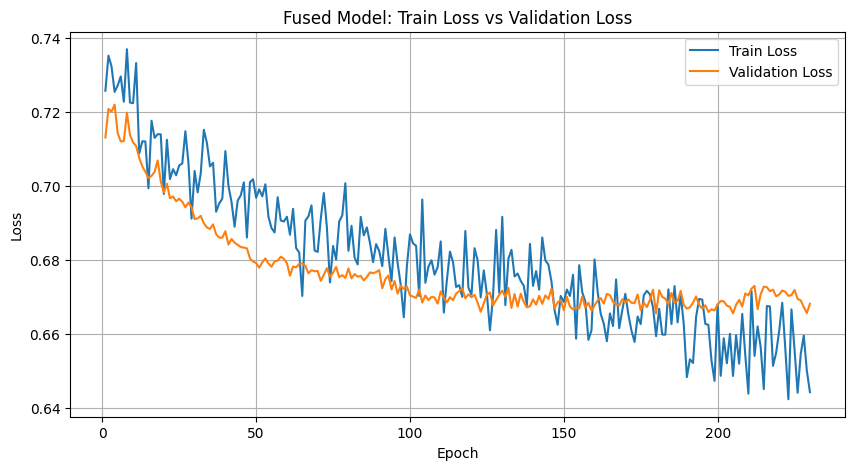

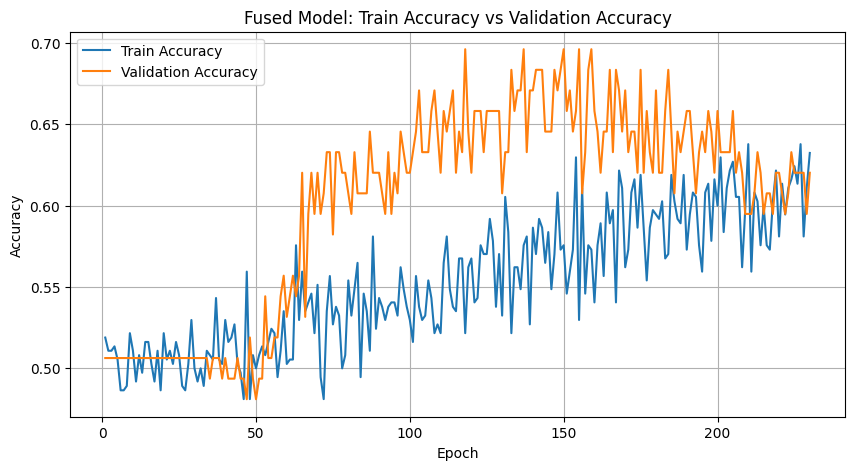

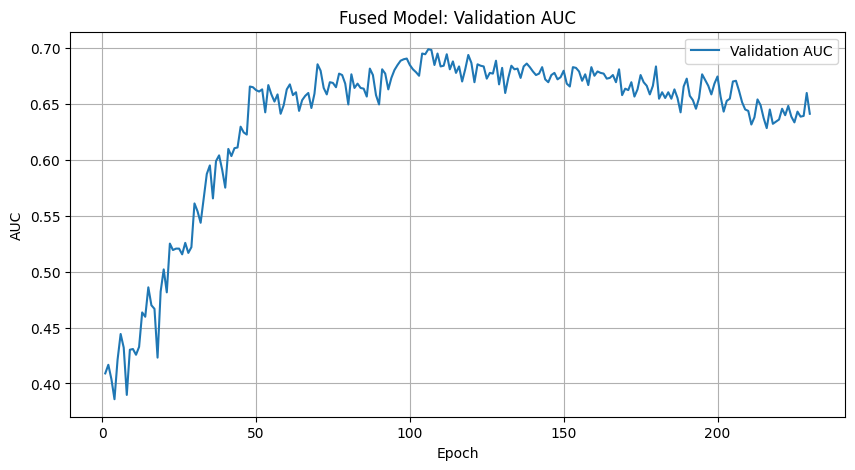

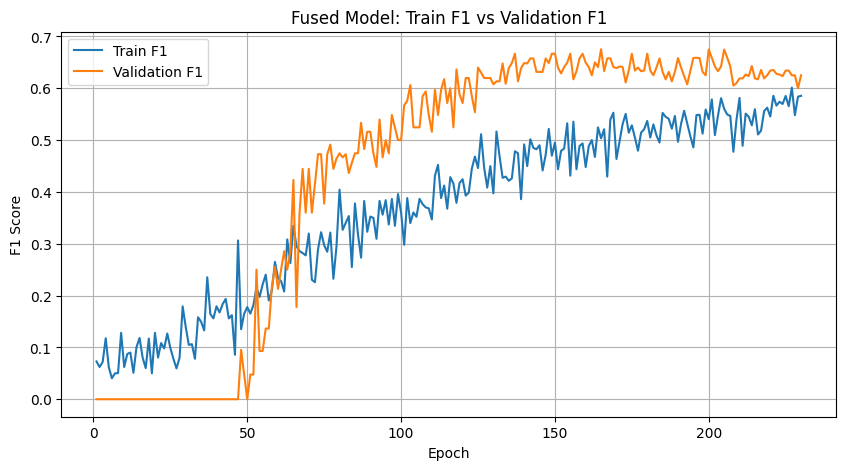

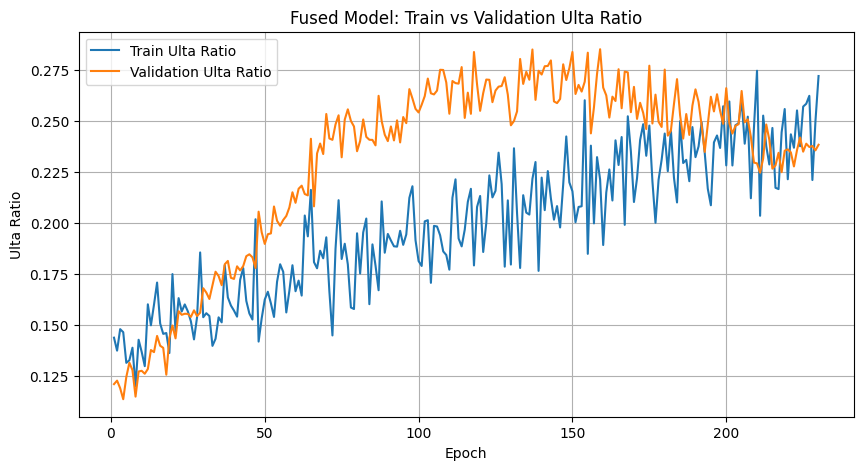

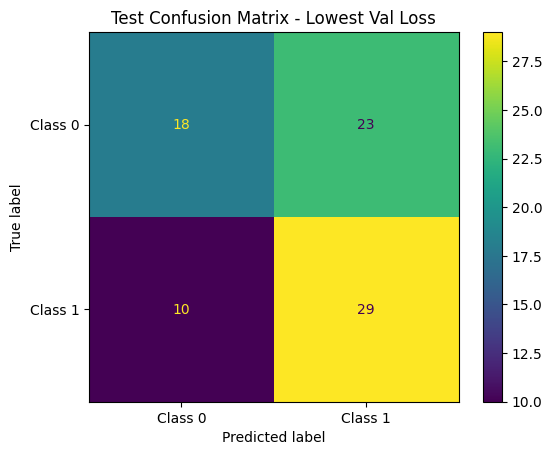

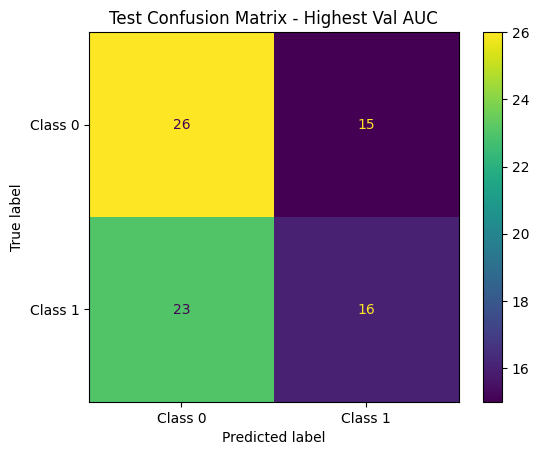

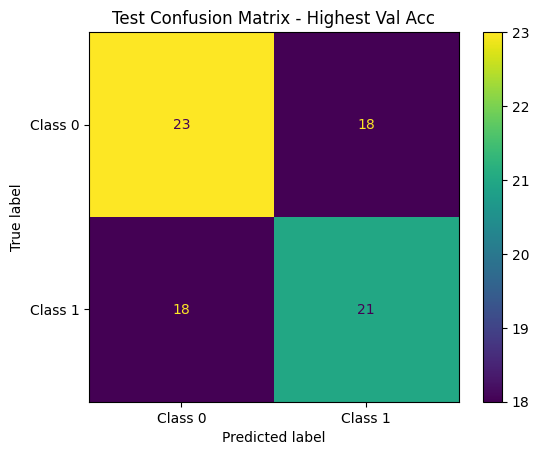

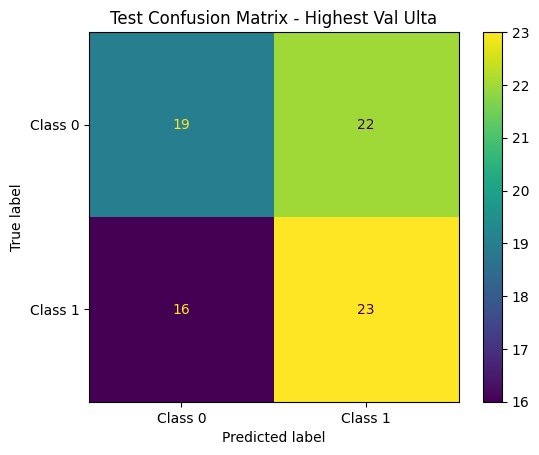

In [805]:
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

EPOCHS = 900
PATIENCE = 50

LEARNING_RATE = 5e-5
WEIGHT_DECAY = 5e-3

SAVE_LOWEST_VAL_LOSS_PATH = "best_fused_lowest_val_loss.pt"
SAVE_HIGHEST_VAL_AUC_PATH = "best_fused_highest_val_auc.pt"
SAVE_HIGHEST_VAL_ACC_PATH = "best_fused_highest_val_acc.pt"
SAVE_HIGHEST_VAL_ULTA_RATIO_PATH = "best_fused_highest_val_ulta_ratio.pt"

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

history = {
    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_bal_acc": [],
    "val_bal_acc": [],

    "train_auc": [],
    "val_auc": [],

    "train_f1": [],
    "val_f1": [],

    "train_ulta_ratio": [],
    "val_ulta_ratio": []
}

best_val_loss = float("inf")
best_val_auc = -float("inf")
best_val_acc = -float("inf")
best_val_ulta_ratio = -float("inf")

best_val_loss_state = None
best_val_auc_state = None
best_val_acc_state = None
best_val_ulta_ratio_state = None

best_val_loss_epoch = None
best_val_auc_epoch = None
best_val_acc_epoch = None
best_val_ulta_ratio_epoch = None

epochs_without_improvement = 0


def safe_auc_score(labels, probs):
    try:
        return roc_auc_score(labels, probs)
    except ValueError:
        return np.nan


def compute_ulta_ratio(auc, acc, loss):
    """
    Custom bounded score.

    Formula:
        ulta_ratio = auc * acc * (1 / (1 + loss))

    Higher is better.

    This rewards:
    - higher AUC
    - higher accuracy
    - lower loss

    If AUC is nan, return nan.
    """

    if np.isnan(auc):
        return np.nan

    return auc * acc * (1.0 / (1.0 + loss))


def evaluate_fused_model(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs_class_1 = []

    with torch.no_grad():
        for X_seq_batch, X_feat_batch, y_batch in data_loader:
            X_seq_batch = X_seq_batch.to(device)
            X_feat_batch = X_feat_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_seq_batch, X_feat_batch)
            loss = criterion(logits, y_batch)

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            batch_size = y_batch.size(0)
            total_loss += loss.item() * batch_size

            all_labels.extend(y_batch.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())

            if probs.shape[1] == 2:
                all_probs_class_1.extend(probs[:, 1].detach().cpu().numpy())
            else:
                all_probs_class_1.extend([np.nan] * batch_size)

    avg_loss = total_loss / len(data_loader.dataset)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs_class_1 = np.array(all_probs_class_1)

    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    auc = safe_auc_score(all_labels, all_probs_class_1)

    ulta_ratio = compute_ulta_ratio(
        auc=auc,
        acc=acc,
        loss=avg_loss
    )

    return {
        "loss": avg_loss,
        "acc": acc,
        "bal_acc": bal_acc,
        "auc": auc,
        "f1": f1,
        "ulta_ratio": ulta_ratio,
        "labels": all_labels,
        "preds": all_preds,
        "probs_class_1": all_probs_class_1
    }


for epoch in range(1, EPOCHS + 1):
    model.train()

    running_train_loss = 0.0

    train_labels = []
    train_preds = []
    train_probs_class_1 = []

    for X_seq_batch, X_feat_batch, y_batch in train_loader:
        X_seq_batch = X_seq_batch.to(device)
        X_feat_batch = X_feat_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_seq_batch, X_feat_batch)
        loss = criterion(logits, y_batch)

        loss.backward()

        # Useful for LSTM stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        batch_size = y_batch.size(0)
        running_train_loss += loss.item() * batch_size

        train_labels.extend(y_batch.detach().cpu().numpy())
        train_preds.extend(preds.detach().cpu().numpy())

        if probs.shape[1] == 2:
            train_probs_class_1.extend(probs[:, 1].detach().cpu().numpy())
        else:
            train_probs_class_1.extend([np.nan] * batch_size)

    train_loss = running_train_loss / len(train_loader.dataset)

    train_labels = np.array(train_labels)
    train_preds = np.array(train_preds)
    train_probs_class_1 = np.array(train_probs_class_1)

    train_acc = accuracy_score(train_labels, train_preds)
    train_bal_acc = balanced_accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, zero_division=0)
    train_auc = safe_auc_score(train_labels, train_probs_class_1)

    train_ulta_ratio = compute_ulta_ratio(
        auc=train_auc,
        acc=train_acc,
        loss=train_loss
    )

    val_results = evaluate_fused_model(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=device
    )

    val_loss = val_results["loss"]
    val_acc = val_results["acc"]
    val_bal_acc = val_results["bal_acc"]
    val_auc = val_results["auc"]
    val_f1 = val_results["f1"]
    val_ulta_ratio = val_results["ulta_ratio"]

    # -------------------------
    # Save history
    # -------------------------

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_bal_acc"].append(train_bal_acc)
    history["val_bal_acc"].append(val_bal_acc)

    history["train_auc"].append(train_auc)
    history["val_auc"].append(val_auc)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    history["train_ulta_ratio"].append(train_ulta_ratio)
    history["val_ulta_ratio"].append(val_ulta_ratio)

    improved = False

    # -------------------------
    # Save lowest val loss
    # -------------------------

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_loss_state = copy.deepcopy(model.state_dict())
        best_val_loss_epoch = epoch

        # torch.save(best_val_loss_state, SAVE_LOWEST_VAL_LOSS_PATH)

        improved = True

    # -------------------------
    # Save highest val AUC
    # -------------------------

    if not np.isnan(val_auc) and val_auc > best_val_auc:
        best_val_auc = val_auc
        best_val_auc_state = copy.deepcopy(model.state_dict())
        best_val_auc_epoch = epoch

        # torch.save(best_val_auc_state, SAVE_HIGHEST_VAL_AUC_PATH)

        improved = True

    # -------------------------
    # Save highest val accuracy
    # -------------------------

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_acc_state = copy.deepcopy(model.state_dict())
        best_val_acc_epoch = epoch

        # torch.save(best_val_acc_state, SAVE_HIGHEST_VAL_ACC_PATH)

        improved = True

    # -------------------------
    # Save highest val ulta ratio
    # -------------------------

    if not np.isnan(val_ulta_ratio) and val_ulta_ratio > best_val_ulta_ratio:
        best_val_ulta_ratio = val_ulta_ratio
        best_val_ulta_ratio_state = copy.deepcopy(model.state_dict())
        best_val_ulta_ratio_epoch = epoch

        # torch.save(best_val_ulta_ratio_state, SAVE_HIGHEST_VAL_ULTA_RATIO_PATH)

        improved = True

    if improved:
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch [{epoch:03d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Bal Acc: {val_bal_acc:.4f} | "
        f"Val AUC: {val_auc:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Val Ulta: {val_ulta_ratio:.4f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch} epochs.")
        break


# ============================================================
# TRAINING COMPLETE
# ============================================================

print("\n================ TRAINING COMPLETE ================")
print(f"Best Lowest Val Loss : {best_val_loss:.4f} at epoch {best_val_loss_epoch}")
print(f"Best Highest Val AUC  : {best_val_auc:.4f} at epoch {best_val_auc_epoch}")
print(f"Best Highest Val Acc  : {best_val_acc:.4f} at epoch {best_val_acc_epoch}")
print(f"Best Highest Ulta     : {best_val_ulta_ratio:.4f} at epoch {best_val_ulta_ratio_epoch}")

print("\nSaved models:")
print(SAVE_LOWEST_VAL_LOSS_PATH)
print(SAVE_HIGHEST_VAL_AUC_PATH)
print(SAVE_HIGHEST_VAL_ACC_PATH)
print(SAVE_HIGHEST_VAL_ULTA_RATIO_PATH)


# ============================================================
# TEST BEST MODELS
# ============================================================

def test_saved_fused_state(model, state_dict, test_loader, criterion, device, model_name):
    if state_dict is None:
        raise ValueError(f"No saved state found for {model_name}.")

    model.load_state_dict(state_dict)
    model.to(device)

    results = evaluate_fused_model(
        model=model,
        data_loader=test_loader,
        criterion=criterion,
        device=device
    )

    return {
        "name": model_name,
        "loss": results["loss"],
        "acc": results["acc"],
        "bal_acc": results["bal_acc"],
        "auc": results["auc"],
        "f1": results["f1"],
        "ulta_ratio": results["ulta_ratio"],
        "labels": results["labels"],
        "preds": results["preds"],
        "probs_class_1": results["probs_class_1"]
    }


test_results = []

test_results.append(
    test_saved_fused_state(
        model=model,
        state_dict=best_val_loss_state,
        test_loader=test_loader,
        criterion=criterion,
        device=device,
        model_name="Lowest Val Loss"
    )
)

test_results.append(
    test_saved_fused_state(
        model=model,
        state_dict=best_val_auc_state,
        test_loader=test_loader,
        criterion=criterion,
        device=device,
        model_name="Highest Val AUC"
    )
)

test_results.append(
    test_saved_fused_state(
        model=model,
        state_dict=best_val_acc_state,
        test_loader=test_loader,
        criterion=criterion,
        device=device,
        model_name="Highest Val Acc"
    )
)

test_results.append(
    test_saved_fused_state(
        model=model,
        state_dict=best_val_ulta_ratio_state,
        test_loader=test_loader,
        criterion=criterion,
        device=device,
        model_name="Highest Val Ulta"
    )
)

print("\n================ TEST COMPARISON ================")

print(
    f"{'Model':<24} "
    f"{'Test Loss':<12} "
    f"{'Test Acc':<10} "
    f"{'Test Bal Acc':<14} "
    f"{'Test AUC':<10} "
    f"{'Test F1':<10} "
    f"{'Test Ulta':<12}"
)

print("-" * 100)

for result in test_results:
    print(
        f"{result['name']:<24} "
        f"{result['loss']:<12.4f} "
        f"{result['acc']:<10.4f} "
        f"{result['bal_acc']:<14.4f} "
        f"{result['auc']:<10.4f} "
        f"{result['f1']:<10.4f} "
        f"{result['ulta_ratio']:<12.4f}"
    )


for result in test_results:
    print(f"\n================ {result['name']} TEST REPORT ================")

    print(
        classification_report(
            result["labels"],
            result["preds"],
            zero_division=0
        )
    )

epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history["train_loss"], label="Train Loss")
plt.plot(epochs_ran, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fused Model: Train Loss vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_ran, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fused Model: Train Accuracy vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history["val_auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Fused Model: Validation AUC")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history["train_f1"], label="Train F1")
plt.plot(epochs_ran, history["val_f1"], label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Fused Model: Train F1 vs Validation F1")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history["train_ulta_ratio"], label="Train Ulta Ratio")
plt.plot(epochs_ran, history["val_ulta_ratio"], label="Validation Ulta Ratio")
plt.xlabel("Epoch")
plt.ylabel("Ulta Ratio")
plt.title("Fused Model: Train vs Validation Ulta Ratio")
plt.legend()
plt.grid(True)
plt.show()


for result in test_results:
    cm = confusion_matrix(result["labels"], result["preds"])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Class 0", "Class 1"]
    )

    disp.plot(values_format="d")
    plt.title(f"Test Confusion Matrix - {result['name']}")
    plt.grid(False)
    plt.show()